In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = "/content/AQI-and-Lat-Long-of-Countries.csv"
data = pd.read_csv(file_path)

In [ ]:
print("Dataset shape:", data.shape)
print("\nColumns:", data.columns.tolist())
print("\nMissing values:\n", data.isnull().sum())

Dataset shape: (16695, 7)

Columns: ['AQI Value', 'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value', 'lat', 'lng']

Missing values:
 AQI Value          0
CO AQI Value       0
Ozone AQI Value    0
NO2 AQI Value      0
PM2.5 AQI Value    0
lat                0
lng                0
dtype: int64


In [ ]:
print(data.head())

   AQI Value  CO AQI Value  Ozone AQI Value  NO2 AQI Value  PM2.5 AQI Value  \
0         51             1               36              0               51   
1         41             1                5              1               41   
2         41             1                5              1               41   
3         66             1               39              2               66   
4         34             1               34              0               20   

       lat      lng  
0  44.7444  44.2031  
1  -5.2900 -44.4900  
2 -11.2958 -41.9869  
3  37.1667  15.1833  
4  53.0167  20.8833  


/tmp/ipython-input-1007357635.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_values.index, y=mean_values.values, palette="coolwarm")


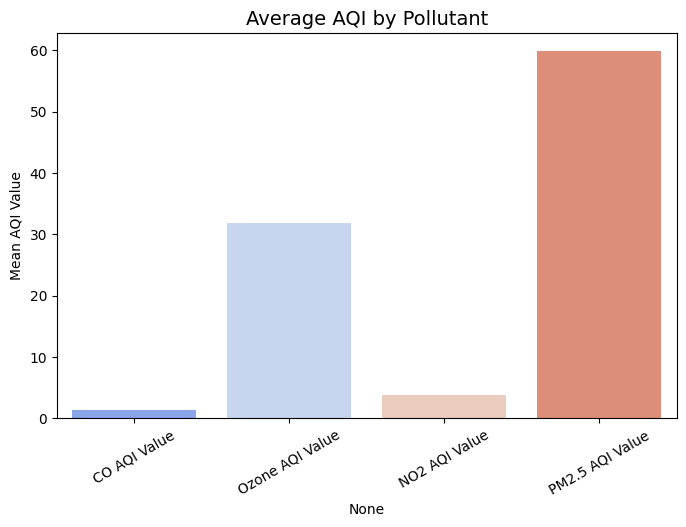

In [ ]:
pollutants = ['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']
mean_values = data[pollutants].mean()

plt.figure(figsize=(8, 5))
sns.barplot(x=mean_values.index, y=mean_values.values, palette="coolwarm")
plt.title("Average AQI by Pollutant", fontsize=14)
plt.ylabel("Mean AQI Value")
plt.xticks(rotation=30)
plt.show()

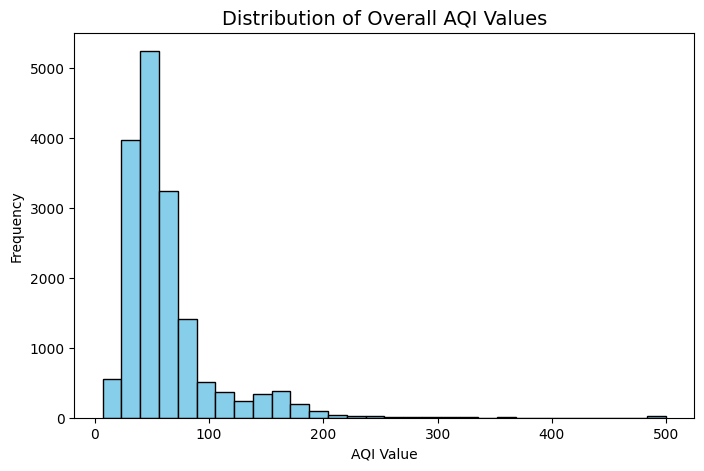

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(data['AQI Value'], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Overall AQI Values", fontsize=14)
plt.xlabel("AQI Value")
plt.ylabel("Frequency")
plt.show()

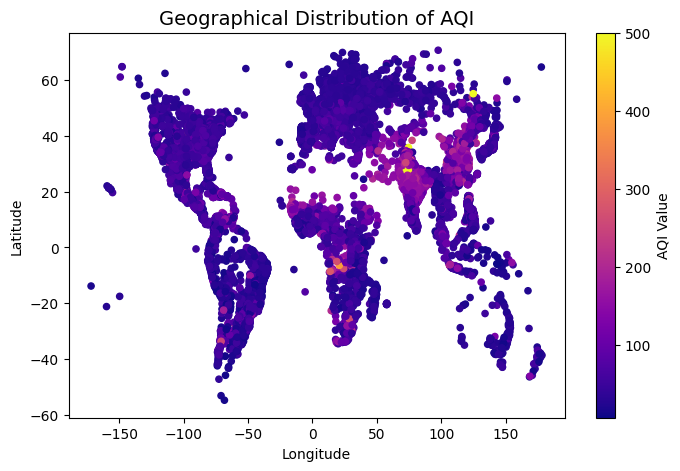

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(data['lng'], data['lat'], c=data['AQI Value'], cmap='plasma', s=20)
plt.colorbar(label='AQI Value')
plt.title("Geographical Distribution of AQI", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

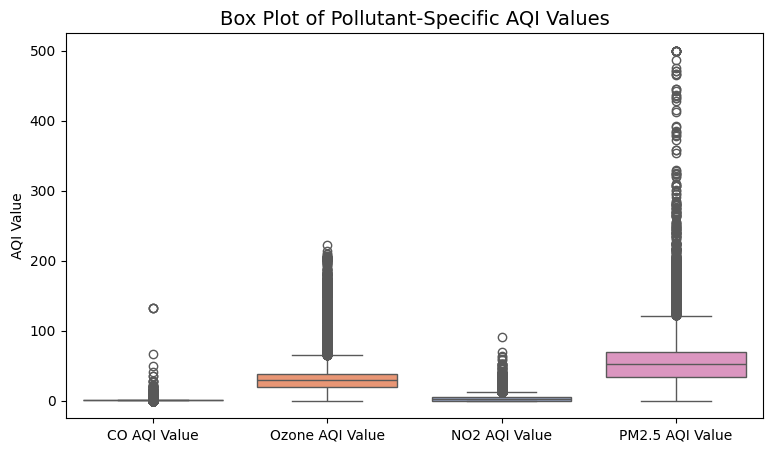

In [ ]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=data[pollutants], palette="Set2")
plt.title("Box Plot of Pollutant-Specific AQI Values", fontsize=14)
plt.ylabel("AQI Value")
plt.show()

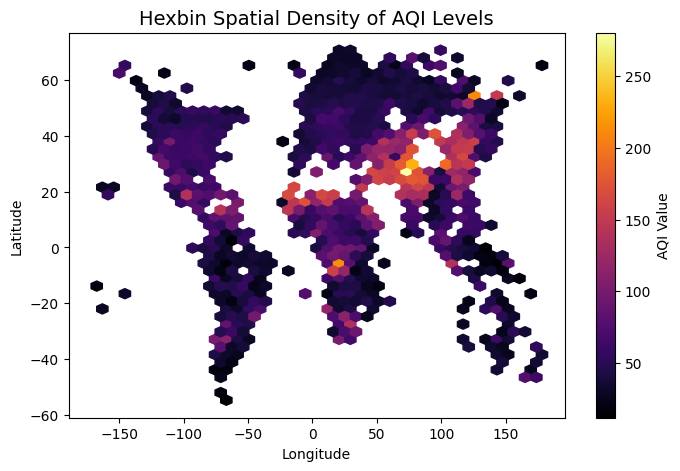

In [ ]:
# Hexbin Plot – Longitude vs Latitude (colored by AQI)
plt.figure(figsize=(8, 5))
plt.hexbin(data['lng'], data['lat'], C=data['AQI Value'], gridsize=40, cmap='inferno')
plt.colorbar(label='AQI Value')
plt.title("Hexbin Spatial Density of AQI Levels", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


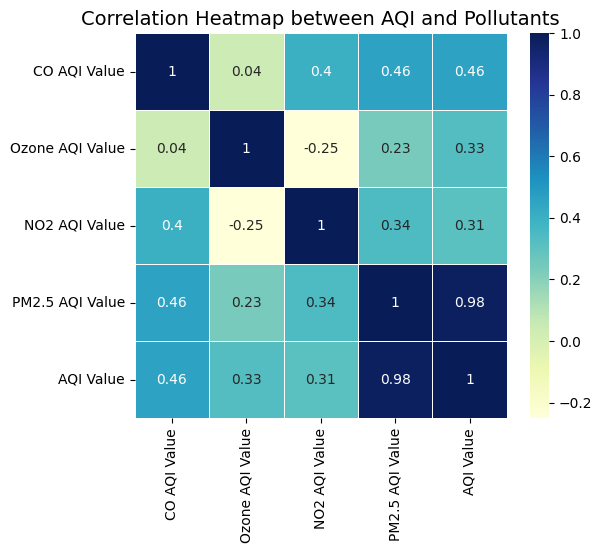

In [ ]:
plt.figure(figsize=(6, 5))
corr_matrix = data[pollutants + ['AQI Value']].corr()
sns.heatmap(corr_matrix, annot=True, cmap="YlGnBu", linewidths=0.5)
plt.title("Correlation Heatmap between AQI and Pollutants", fontsize=14)
plt.show()

In [ ]:
correlations = data[pollutants + ['AQI Value']].corr()['AQI Value'].sort_values(ascending=False)
print("\nCorrelation of pollutants with AQI Value:")
print(correlations)


Correlation of pollutants with AQI Value:
AQI Value          1.000000
PM2.5 AQI Value    0.980360
CO AQI Value       0.458523
Ozone AQI Value    0.327956
NO2 AQI Value      0.308858
Name: AQI Value, dtype: float64
